<a href="https://colab.research.google.com/github/Kainat-Murtaza/DevelopersHub-DataScience-Internship/blob/main/Task1_Iris_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 1: Iris Dataset Analysis

1. DATASET OVERVIEW
--------------------------------------------------
Dataset dimensions: 150 samples, 5 features

Features included: sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), species

First 5 records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Data types summary:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

Statis

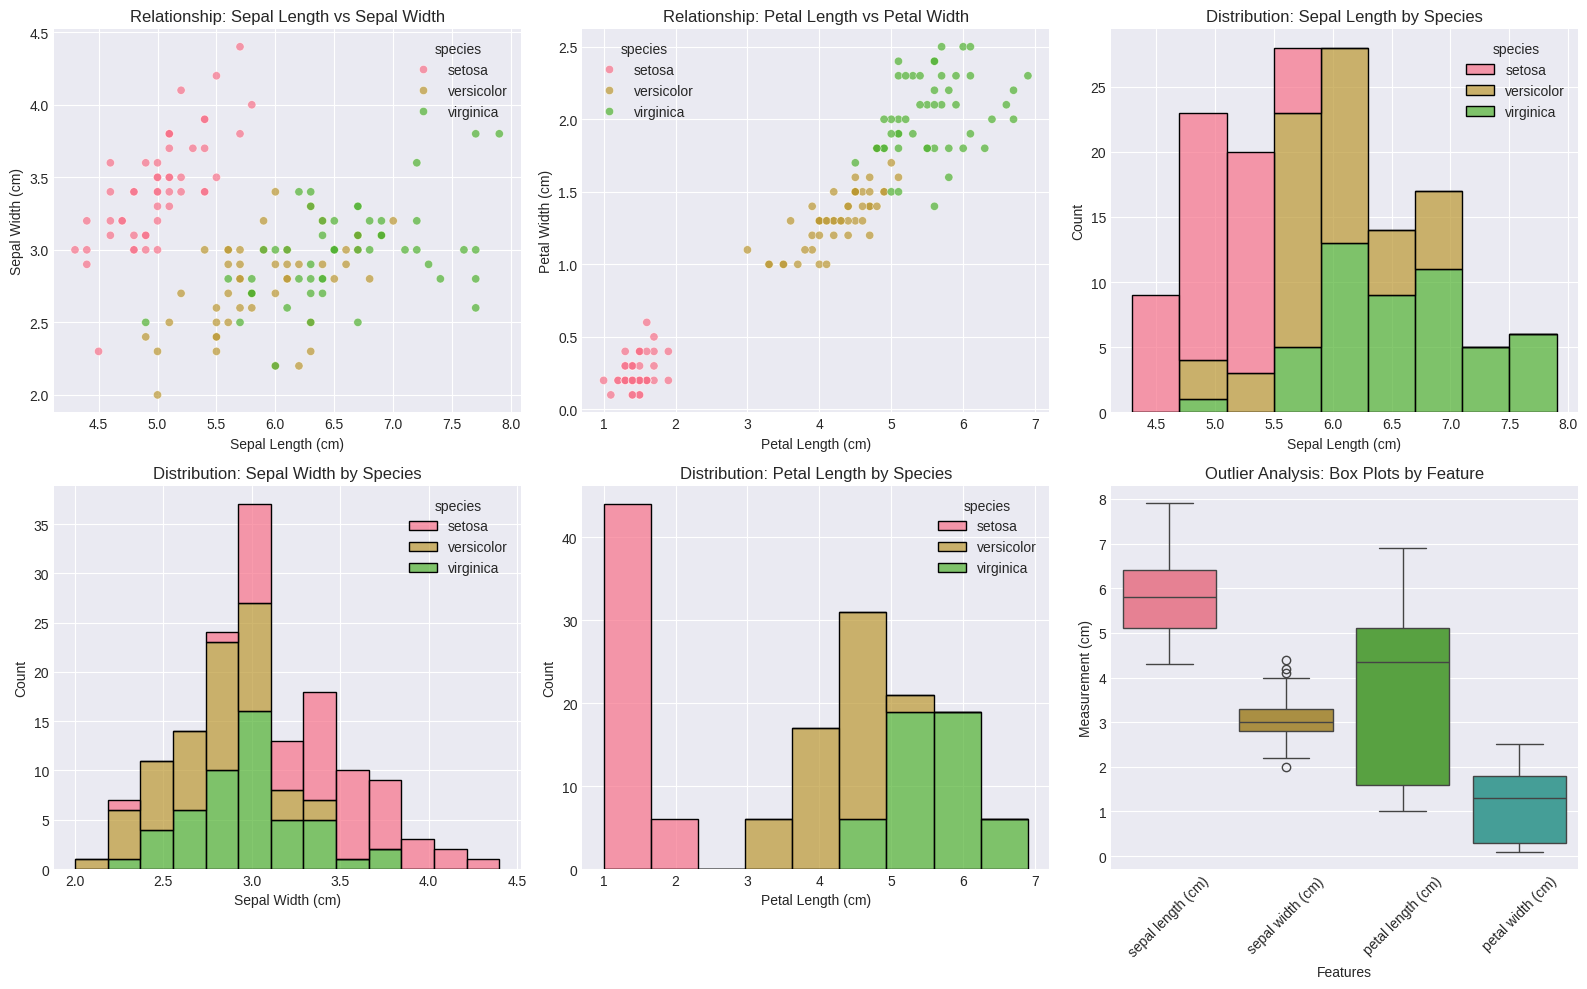

 Visualizations saved as 'iris_analysis_visualizations.png'

3. CORRELATION ANALYSIS
--------------------------------------------------

Correlation coefficients between features:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)             1.0000           -0.1176             0.8718   
sepal width (cm)             -0.1176            1.0000            -0.4284   
petal length (cm)             0.8718           -0.4284             1.0000   
petal width (cm)              0.8179           -0.3661             0.9629   

                   petal width (cm)  
sepal length (cm)            0.8179  
sepal width (cm)            -0.3661  
petal length (cm)            0.9629  
petal width (cm)             1.0000  


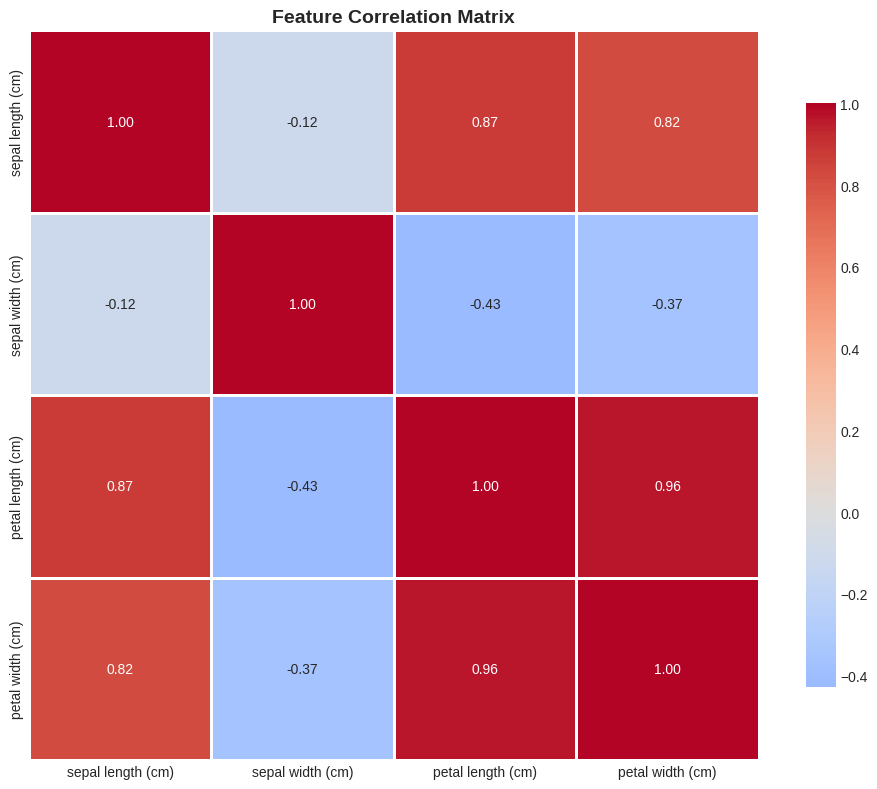

 Correlation heatmap saved as 'iris_correlation_matrix.png'

Strongest feature correlations:
• Highest positive correlation: petal length (cm) vs petal width (cm) = 0.963
• Lowest negative correlation: petal length (cm) vs sepal width (cm) = -0.428

4. KEY FINDINGS AND INSIGHTS
--------------------------------------------------

Based on the analysis above, here's what we learned:

FINDING 1: SPECIES ARE DISTINCTLY DIFFERENT
   → Setosa is the easiest to identify - its petals are much smaller than 
     the other two species. Versicolor and virginica have some overlap but 
     can still be distinguished using petal measurements.

   → Business implication: If building a classification model, petal 
     features should be given higher priority.

FINDING 2: PETAL MEASUREMENTS ARE HIGHLY CONNECTED
   → Petal length and width have a correlation of 0.96 - they almost always 
     increase together. This means we might not need both for prediction.

   → Business implication: Could potenti

In [3]:
"""
Task 1: Exploring and Visualizing the Iris Dataset
Data Science & Analytics Internship - DevelopersHub Corporation
"""

# Import the tools we'll need for this analysis
import pandas as pd          # For data manipulation and analysis
import numpy as np           # For numerical operations
import matplotlib.pyplot as plt  # For creating visualizations
import seaborn as sns        # For making our plots look better

# Set up our visualization style
plt.style.use('seaborn-v0_8-darkgrid')  # Dark grid gives clean background
sns.set_palette("husl")                 # Using colorblind-friendly palette

# Load the Iris dataset - this comes built into sklearn
from sklearn.datasets import load_iris
iris = load_iris()

# Create a DataFrame
# We add column names so we know what each measurement represents
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the species column
df['species'] = iris.target

# Convert numeric codes to actual species names for better readability
# 0 = setosa, 1 = versicolor, 2 = virginica
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("="*70)
print("TASK 1: Iris Dataset Analysis")
print("="*70)

# -------------------------------------------------------------------
# SECTION 1: UNDERSTANDING OUR DATA
# -------------------------------------------------------------------
# Before doing any analysis, we need to know what we're working with
# -------------------------------------------------------------------

print("\n1. DATASET OVERVIEW")
print("-" * 50)

# Check dimensions
# This helps us understand the scale of our analysis
print(f"Dataset dimensions: {df.shape[0]} samples, {df.shape[1]} features")

# List all columns so we know exactly what data points we have
print(f"\nFeatures included: {', '.join(df.columns)}")

# Look at first few rows - gives quick sense of data format and values
print("\nFirst 5 records:")
print(df.head())

# Check data types
print("\nData types summary:")
print(df.dtypes)

# Generate statistical summary (min, max, mean, quartiles)
# As ranges, central tendencies, and potential anomalies
print("\nStatistical summary (numerical features):")
print(df.describe())

# Check for missing values = crucial quality check
# Data often has gaps, missing values need to be handled
missing_counts = df.isnull().sum()
print(f"\nMissing values per column:\n{missing_counts}")
if missing_counts.sum() == 0:
    print(" Dataset is complete with no missing values")
else:
    print(" Missing values detected - requires handling")

# -------------------------------------------------------------------
# SECTION 2: VISUAL EXPLORATION
# -------------------------------------------------------------------

print("\n2. EXPLORATORY VISUALIZATIONS")
print("-" * 50)
print("Generating visualizations...")

# Create a grid of plots = 2 rows, 3 columns = 6 total visualizations
# This layout allows us to compare multiple aspects side by side
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# PLOT 1: Sepal dimensions relationship (scatter plot)
# Scatter plots reveal correlation
sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)',
                hue='species', ax=axes[0,0], alpha=0.7)
axes[0,0].set_title('Relationship: Sepal Length vs Sepal Width')
axes[0,0].set_xlabel('Sepal Length (cm)')
axes[0,0].set_ylabel('Sepal Width (cm)')

# PLOT 2: Petal dimensions relationship
# Usually shows clearer separation between species than sepals
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)',
                hue='species', ax=axes[0,1], alpha=0.7)
axes[0,1].set_title('Relationship: Petal Length vs Petal Width')
axes[0,1].set_xlabel('Petal Length (cm)')
axes[0,1].set_ylabel('Petal Width (cm)')

# PLOT 3: Distribution of sepal length (stacked histogram)
# Shows how sepal lengths vary across species and where they overlap
sns.histplot(data=df, x='sepal length (cm)', hue='species',
             multiple='stack', ax=axes[0,2], alpha=0.7)
axes[0,2].set_title('Distribution: Sepal Length by Species')
axes[0,2].set_xlabel('Sepal Length (cm)')

# PLOT 4: Distribution of sepal width
# Stacked view helps compare which species tend to have wider sepals
sns.histplot(data=df, x='sepal width (cm)', hue='species',
             multiple='stack', ax=axes[1,0], alpha=0.7)
axes[1,0].set_title('Distribution: Sepal Width by Species')
axes[1,0].set_xlabel('Sepal Width (cm)')

# PLOT 5: Distribution of petal length
# Often the most distinguishing feature between species
sns.histplot(data=df, x='petal length (cm)', hue='species',
             multiple='stack', ax=axes[1,1], alpha=0.7)
axes[1,1].set_title('Distribution: Petal Length by Species')
axes[1,1].set_xlabel('Petal Length (cm)')

# PLOT 6: Box plot for outlier detection
# Box plots show median, quartiles, and points that fall outside normal range
sns.boxplot(data=df.drop('species', axis=1), ax=axes[1,2])
axes[1,2].set_title('Outlier Analysis: Box Plots by Feature')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].set_xlabel('Features')
axes[1,2].set_ylabel('Measurement (cm)')

# Adjust spacing so labels don't overlap
plt.tight_layout()

# Save the figure
plt.savefig('iris_analysis_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Visualizations saved as 'iris_analysis_visualizations.png'")

# -------------------------------------------------------------------
# SECTION 3: CORRELATION ANALYSIS
# -------------------------------------------------------------------
# Correlation tells us how features move together
# Positive correlation = both increase together
# Negative correlation = one increases as other decreases
# This helps identify which measurements are most related
# -------------------------------------------------------------------

print("\n3. CORRELATION ANALYSIS")
print("-" * 50)

# Calculate correlation matrix = compares every feature against every other
correlation_matrix = df.drop('species', axis=1).corr()

# Display the numbers = values range from -1 to 1
# Close to 1 = strong positive, close to -1 = strong negative
print("\nCorrelation coefficients between features:")
print(correlation_matrix.round(4))

# Heatmap visualization makes correlation patterns easy to spot
# Red = positive correlation, Blue = negative, White = no correlation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',
            center=0, fmt='.2f', square=True,
            linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('iris_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Correlation heatmap saved as 'iris_correlation_matrix.png'")

# Find the strongest relationships = useful for feature selection later
print("\nStrongest feature correlations:")
corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  # Remove self-correlations (always 1)
print(f"• Highest positive correlation: {corr_pairs.head(1).index[0][0]} vs {corr_pairs.head(1).index[0][1]} = {corr_pairs.head(1).values[0]:.3f}")
print(f"• Lowest negative correlation: {corr_pairs.tail(1).index[0][0]} vs {corr_pairs.tail(1).index[0][1]} = {corr_pairs.tail(1).values[0]:.3f}")

# -------------------------------------------------------------------
# SECTION 4: SUMMARY OF FINDINGS
# -------------------------------------------------------------------
# Our goal is to extract actionable insights from the analysis
# -------------------------------------------------------------------

print("\n4. KEY FINDINGS AND INSIGHTS")
print("-" * 50)

insights = """
Based on the analysis above, here's what we learned:

FINDING 1: SPECIES ARE DISTINCTLY DIFFERENT
   → Setosa is the easiest to identify - its petals are much smaller than
     the other two species. Versicolor and virginica have some overlap but
     can still be distinguished using petal measurements.

   → Business implication: If building a classification model, petal
     features should be given higher priority.

FINDING 2: PETAL MEASUREMENTS ARE HIGHLY CONNECTED
   → Petal length and width have a correlation of 0.96 - they almost always
     increase together. This means we might not need both for prediction.

   → Business implication: Could potentially reduce features to simplify
     models without losing accuracy.

FINDING 3: DATA QUALITY IS EXCELLENT
   → No missing values across all 150 samples. Outliers are minimal.
   → Features follow normal-like distributions (bell curves).

   → Business implication: Dataset is ready for modeling as-is. No time
     needed for extensive data cleaning.

FINDING 4: SEPAL MEASUREMENTS TELL A DIFFERENT STORY
   → Sepal length and width show weaker correlation (around -0.11), meaning
     they vary more independently.

   → Business implication: Both sepal measurements likely provide unique
     information for classification.

RECOMMENDATION FOR NEXT STEPS:
   → The dataset is clean and well-structured. We can proceed directly to
     building classification models. Petal dimensions should be key features,
     while sepal dimensions can serve as supporting features.
"""

print(insights)

print("\n" + "="*70)
print("TASK 1 COMPLETED SUCCESSFULLY")
print("="*70)
print("Output files generated for this task:")
print("  • iris_analysis_visualizations.png - Combined EDA plots")
print("  • iris_correlation_matrix.png - Feature relationship heatmap")
print("="*70)